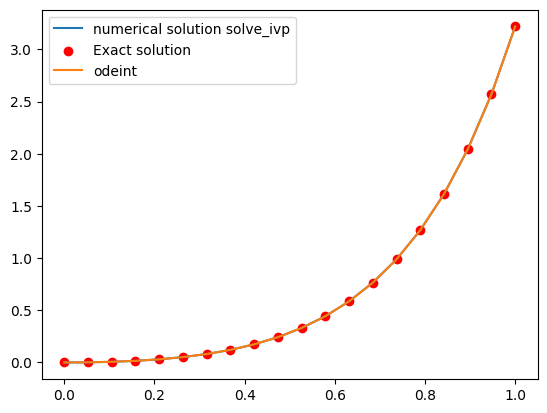

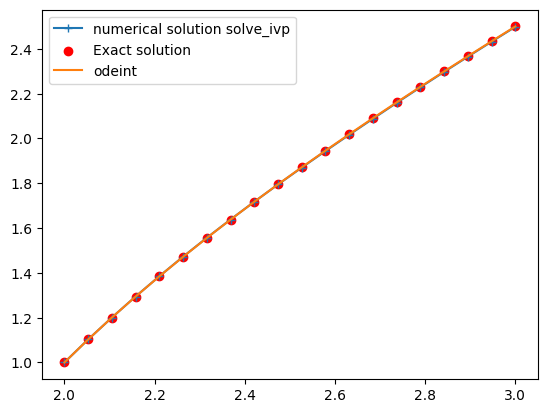

In [23]:
import numpy as np
from scipy.integrate import solve_ivp,odeint
import matplotlib.pyplot as plt
def ode1(t,y):
    return t*np.exp(3*t)-2*y
def ode2(t,y):
    return 1+(t-y)**2
def ode_int1(y,t):
    return t*np.exp(3*t)-2*y
def ode_int2(y,t):
    return 1+(t-y)**2
def exact_soln1(t):
    return (1/5)*t*np.exp(3*t)-(1/25)*np.exp(3*t)+(1/25)*np.exp(-2*t)
def exact_soln2(t):
    return t+(1/(1-t))
t_val=np.linspace(0,1,20)
t_span=[0,1]
y0=[0]
sol=solve_ivp(ode1,t_span,y0,t_eval=t_val)
sol_=odeint(ode_int1,y0,t_val)

plt.plot(sol.t,sol.y[0])

plt.scatter(t_val,exact_soln1(t_val),color='red')
plt.plot(t_val,sol_)

plt.legend(['numerical solution solve_ivp','Exact solution','odeint'])
plt.show()
t_val=np.linspace(2,3,20)
t_span=[2,3]
y0=[1]
sol=solve_ivp(ode2,t_span,y0,t_eval=t_val)
sol_=odeint(ode_int2,y0,t_val)
plt.plot(sol.t,sol.y[0],marker='+')
plt.scatter(t_val,exact_soln2(t_val),color='red')
plt.plot(t_val,sol_)
plt.legend(['numerical solution solve_ivp','Exact solution','odeint'])
plt.show()

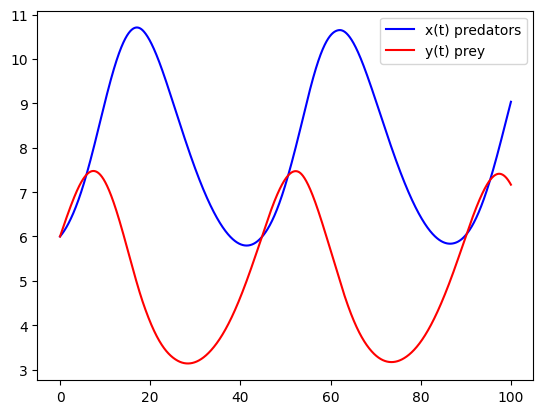

Crossing detected near t = 5.861172234446889 7.3929589953171515


In [51]:
def ode_sys(t,z):
    x,y=z
    dx_dt=-0.1*x+0.02*x*y
    dy_dt=0.2*y-0.025*x*y
    return [dx_dt,dy_dt]
intial=[6,6]
t_span=[0,100]
t_val=np.linspace(0,100,5000)

sol=solve_ivp(ode_sys,t_span,intial,t_eval=t_val)
plt.plot(sol.t,sol.y[0],color='blue')
plt.plot(sol.t,sol.y[1],color='red')
plt.legend(['x(t) predators','y(t) prey'])
plt.show()

x = sol.y[0]
y = sol.y[1]

for i in range(1, len(sol.t)):
    if (x[i-1] - y[i-1])*(x[i] - y[i]) < 0:
        print("Crossing detected near t =", sol.t[i],sol.y[0][i])
        break


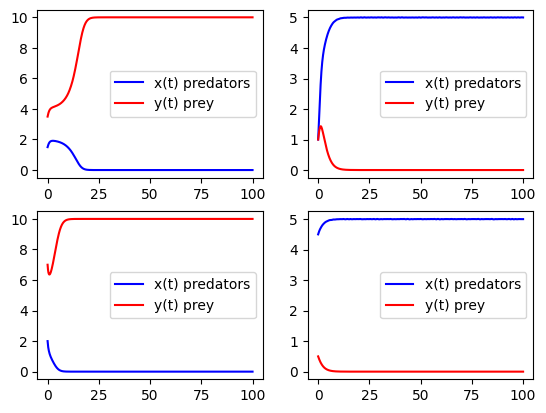

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
def ode_sys(t,z):
    x,y=z
    dx_dt=x*(2-0.4*x-0.3*y)
    dy_dt=y*(1-0.1*y-0.3*x)
    return [dx_dt,dy_dt]
intials=[[1.5,3.5],[1,1],[2,7],[4.5,0.5]]
t_span=[0,100]
t_val=np.linspace(0,100,1000)

for i,intial in enumerate(intials):
    plt.subplot(2,2,i+1)
    sol=solve_ivp(ode_sys,t_span,intial,t_eval=t_val)
    plt.plot(sol.t,sol.y[0],color='blue')
    plt.plot(sol.t,sol.y[1],color='red')
    plt.legend(['x(t) predators','y(t) prey'])
plt.show()



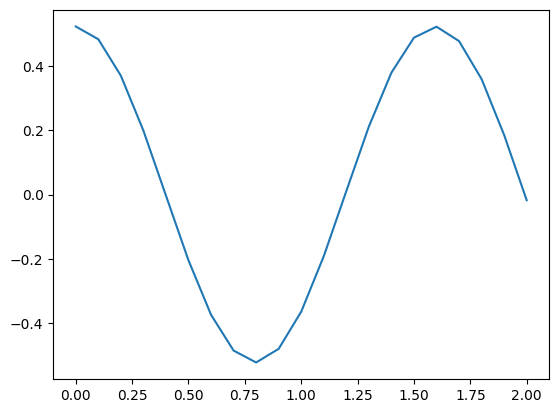

In [8]:
def ode_sys(t,z):
    x,y=z
    dx_dt=y
    dy_dt=-(32.17/2)*np.sin(x)
    return [dx_dt,dy_dt]
initial=[np.pi/6,0]
t_val=np.arange(0,2.1,0.1)
sol=solve_ivp(ode_sys,[0,2],initial,t_eval=t_val)
plt.plot(sol.t,sol.y[0])
plt.show()


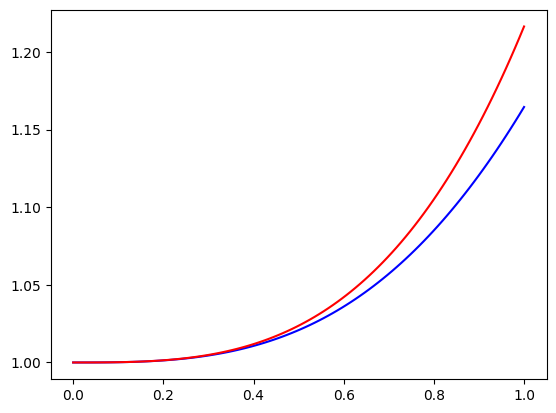

In [11]:
def ode_sys(t,z):
    z1,z2,z3,z4,z5,z6=z
    dz1=z2
    dz2=z3
    dz4=z5
    dz5=z6
    dz6=-z2**3+z2+z1+np.sin(t)
    dz3=-2*z5**2+z4
    return [dz1,dz2,dz3,dz4,dz5,dz6]
intial=[1,0,0,1,0,0]
t_val=np.linspace(0,1,100)
t_span=[0,1]
sol=solve_ivp(ode_sys,t_span,intial,t_eval=t_val)
plt.plot(sol.t,sol.y[0],color='blue')
plt.plot(sol.t,sol.y[3],color='red')
plt.show()



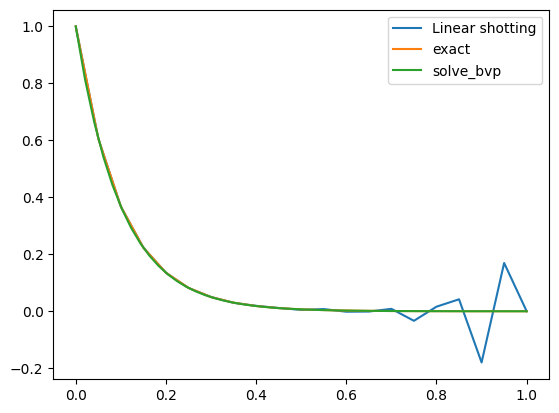

In [23]:
import numpy as np
from scipy.integrate import solve_ivp,solve_bvp
import matplotlib.pyplot as plt
def ode_sys(t,z):
    x,y=z
    dx=y
    dy=100*x
    return [dx,dy]
def exact(x):
    return np.exp(-10*x)
def bc(ya,yb):
    return [ya[0]-1,yb[0]-np.exp(-10)]
t_val=np.arange(0,1.05,0.05)
t_span=[0,1]
initial=[1,0]
sol1=solve_ivp(ode_sys,t_span,initial,t_eval=t_val)
initial=[0,1]
sol2=solve_ivp(ode_sys,t_span,initial,t_eval=t_val)

t_val = np.linspace(0, 1, 50)


y_guess = np.zeros((2, t_val.size))
y_guess[0] = np.linspace(1, np.exp(-10), t_val.size) 
b_sol=solve_bvp(ode_sys,bc,t_val,y_guess)


s=(np.exp(-10)-sol1.y[0][-1])/sol2.y[0][-1]
sol=sol1.y[0]+s*sol2.y[0]
plt.plot(sol1.t,sol,label='Linear shotting')
plt.plot(sol1.t,exact(sol1.t),label='exact')
plt.plot(t_val,b_sol.y[0],label='solve_bvp')
plt.legend()
plt.show()

